In [35]:
# Importar Pandas, Matplotlib e Seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importação dos dados
df = pd.read_csv('data/raw.csv')

In [36]:
# Transformando a coluna 'Data ultimo aumento' para DateTime
df['Data ultimo aumento'] = pd.to_datetime(df['Data ultimo aumento'])
df.dtypes

C:\Users\Enrique\AppData\Local\Temp\ipykernel_13080\1920659316.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Data ultimo aumento'] = pd.to_datetime(df['Data ultimo aumento'])


Idade                               int64
Genero                             object
Nivel Ensino                       object
Area Formacao                      object
Setor                              object
Nivel                              object
Faixa Salarial                     object
Anos experiencia                   object
Faixa Salarial – numero             int64
Data ultimo aumento        datetime64[ns]
dtype: object

---
### 1. Distribuição do nº de funcionários, de acordo com gênero, nível de senioridade e nível de formação

[Text(0, 0, '979.0'), Text(0, 0, '406.0')]

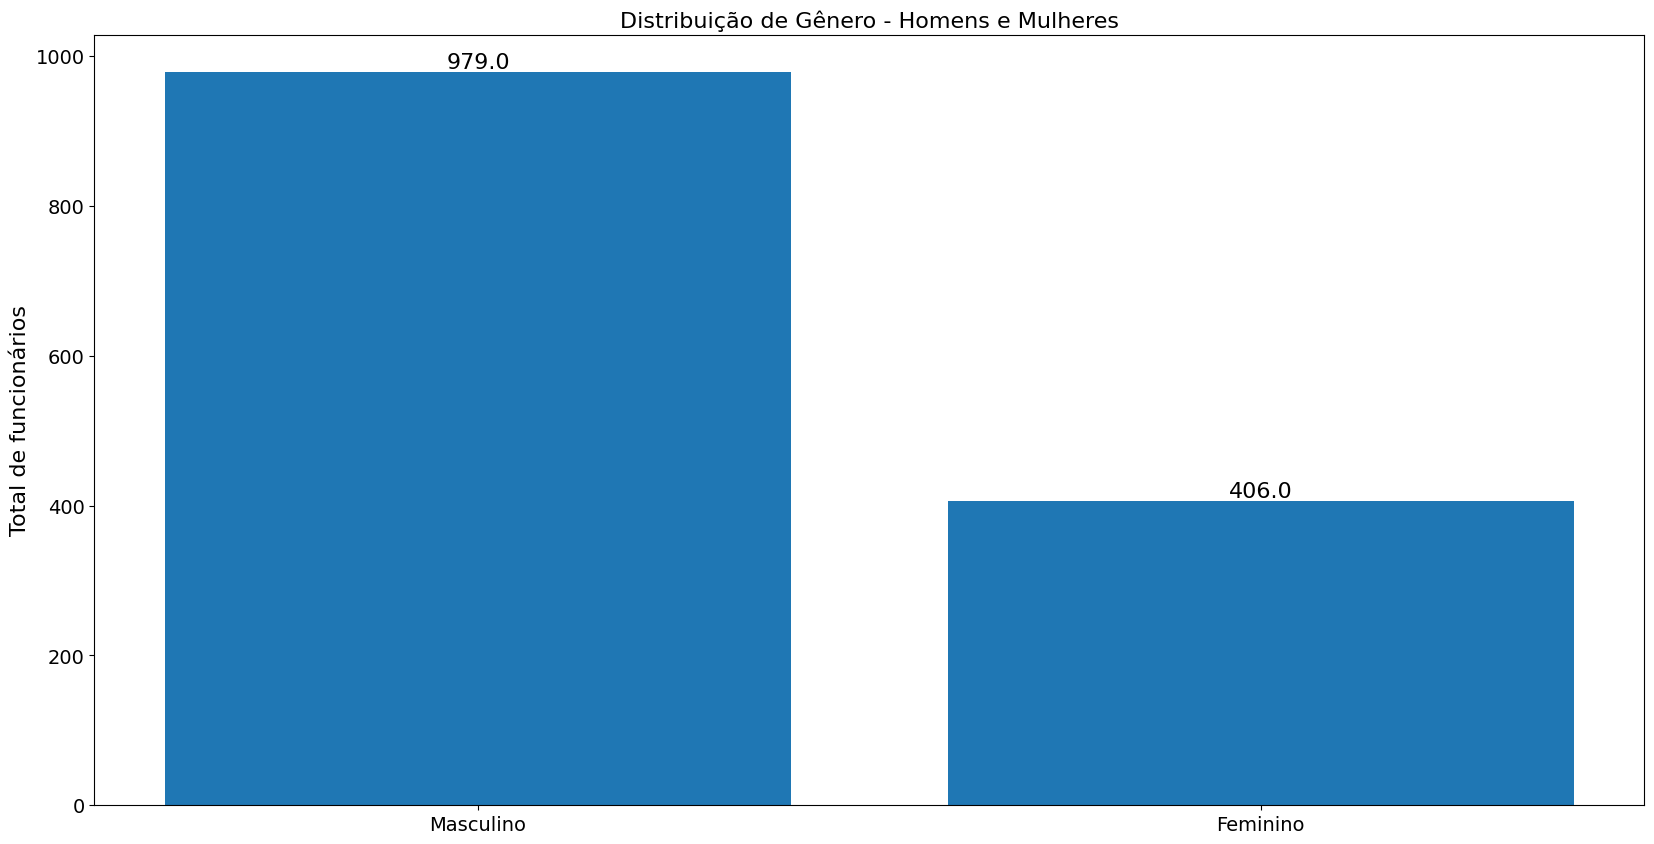

In [37]:
#Gráfico para a distribuição de gênero
plt.figure(figsize=(20, 10))

grafico_1 = plt.bar(df['Genero'].unique(), df['Genero'].value_counts())
plt.title('Distribuição de Gênero - Homens e Mulheres', fontsize=16)
plt.ylabel('Total de funcionários', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.bar_label(grafico_1, fontsize=16, fmt="%.01f", label_type='edge')

[Text(0, 0, '495.0'),
 Text(0, 0, '452.0'),
 Text(0, 0, '185.0'),
 Text(0, 0, '173.0'),
 Text(0, 0, '56.0'),
 Text(0, 0, '24.0')]

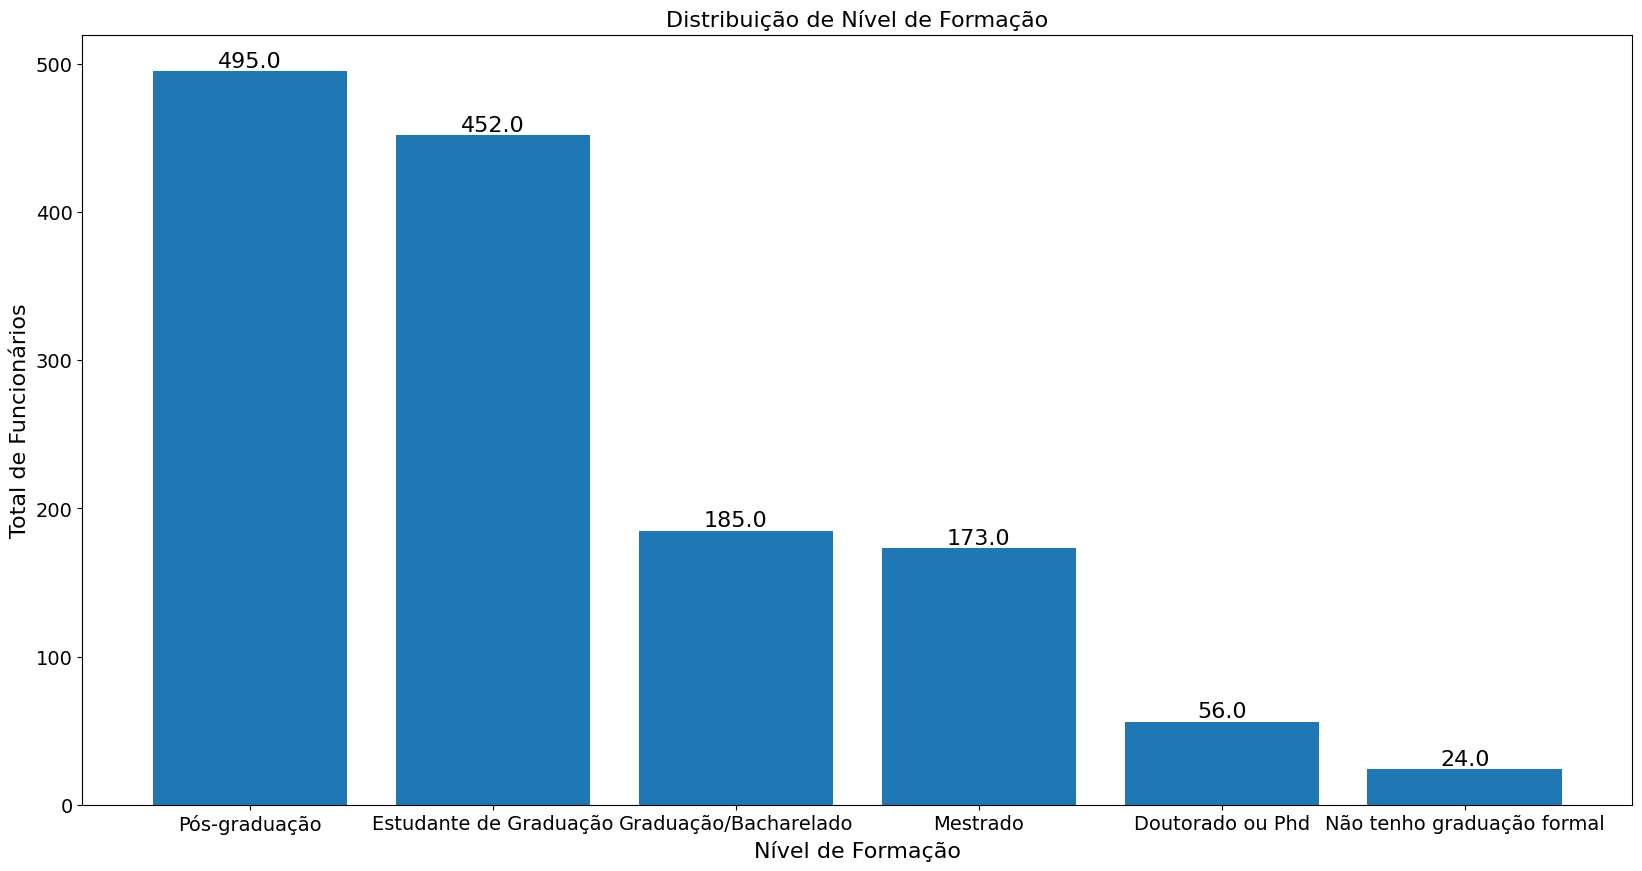

In [38]:
#Gráfico de acordo com o nível de formação

plt.figure(figsize=(20, 10))
grafico_2 = plt.bar(df['Nivel Ensino'].unique(), df['Nivel Ensino'].value_counts())

plt.title('Distribuição de Nível de Formação', fontsize=16)

plt.xlabel('Nível de Formação', fontsize=16)
plt.ylabel('Total de Funcionários', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.bar_label(grafico_2, fontsize=16, fmt="%.01f", label_type='edge')

[Text(0, 0, '440.0'),
 Text(0, 0, '409.0'),
 Text(0, 0, '370.0'),
 Text(0, 0, '166.0')]

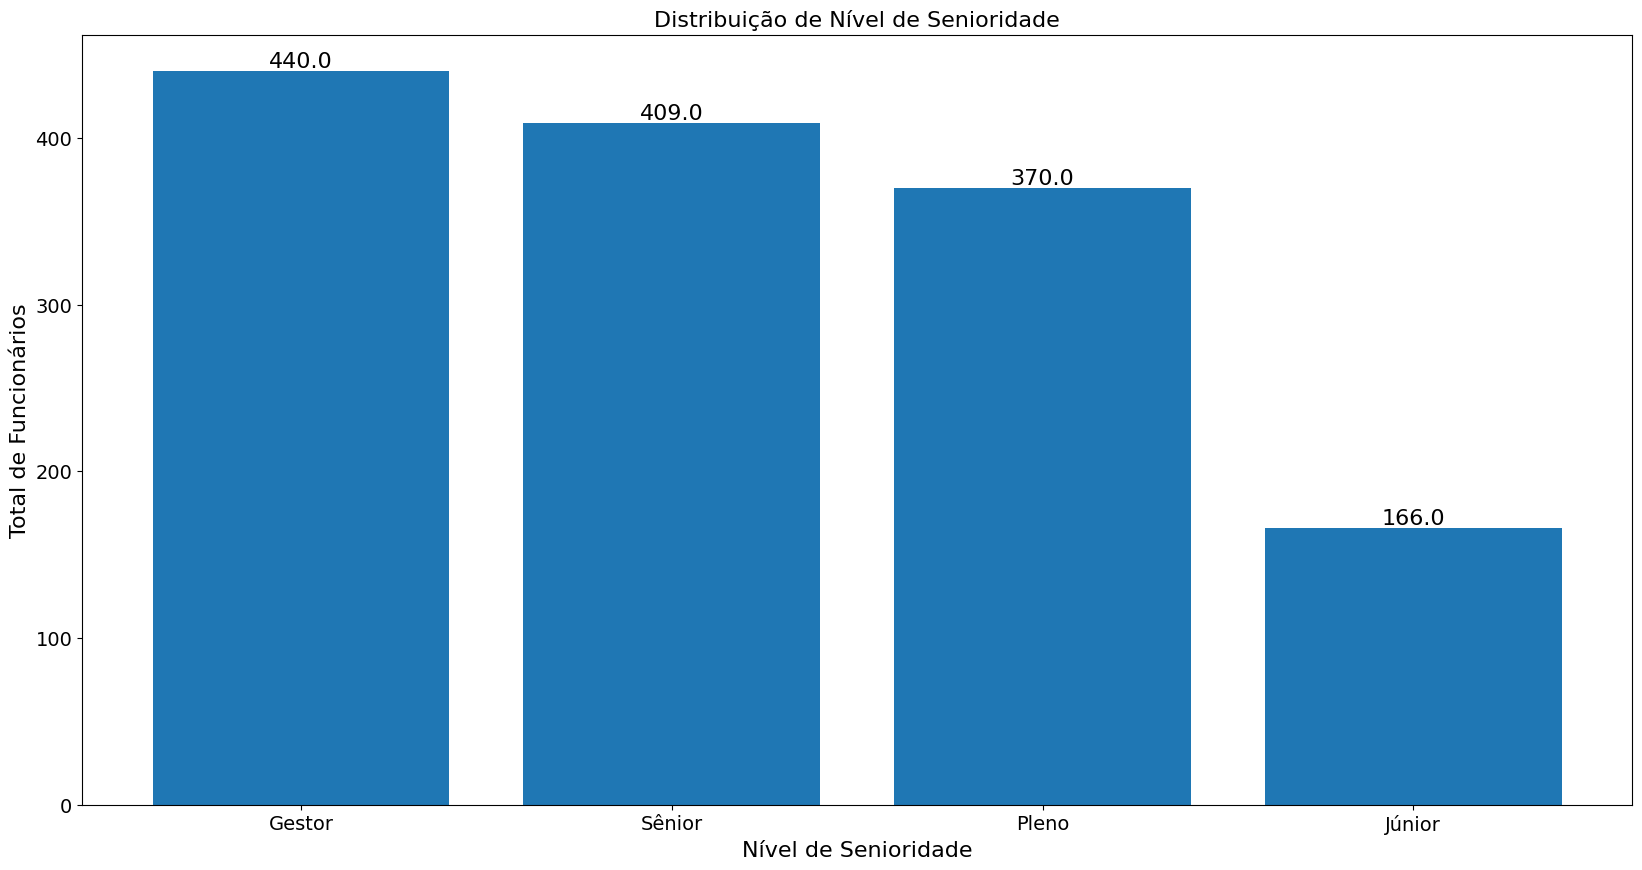

In [39]:
#Gráfico de acordo com o nível de senioridade

plt.figure(figsize=(20, 10))
grafico_3 = plt.bar(df['Nivel'].unique(), df['Nivel'].value_counts())

plt.title('Distribuição de Nível de Senioridade', fontsize=16)

plt.xlabel('Nível de Senioridade', fontsize=16)
plt.ylabel('Total de Funcionários', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.bar_label(grafico_3, fontsize=16, fmt="%.01f", label_type='edge')

---
### 2. Evolução média salarial ao longo do tempo, com base na data de último aumento

In [40]:
# Separação do último aumento por ano
df['Data ultimo aumento - Ano'] = df['Data ultimo aumento'].dt.year

# Transformando a coluna 'Data ultimo aumento - Ano' para string
df['Data ultimo aumento - Ano'] = df['Data ultimo aumento - Ano'].astype(str)

In [41]:
# Calculando a média por ano, para saber se os salários aumentaram ou diminuíram entre 2021 e 2023
media_salarial_ano = df.groupby(['Data ultimo aumento - Ano', 'Genero'])['Faixa Salarial – numero'].mean().round(0)
media_salarial_ano.head()

Data ultimo aumento - Ano  Genero   
2021                       Feminino      9695.0
                           Masculino     9495.0
2022                       Feminino      9331.0
                           Masculino    11271.0
2023                       Feminino      9440.0
Name: Faixa Salarial – numero, dtype: float64

In [42]:
# Utilizando a função reset_index para criar uma ordem e facilitar a criação do gráfico
media_salarial_ano = media_salarial_ano.reset_index(name='Salario Medio')
media_salarial_ano.head()

,Data ultimo aumento - Ano,Genero,Salario Medio
0,2021,Feminino,9695.0
1,2021,Masculino,9495.0
2,2022,Feminino,9331.0
3,2022,Masculino,11271.0
4,2023,Feminino,9440.0


<Axes: xlabel='Data ultimo aumento - Ano', ylabel='Salario Medio'>

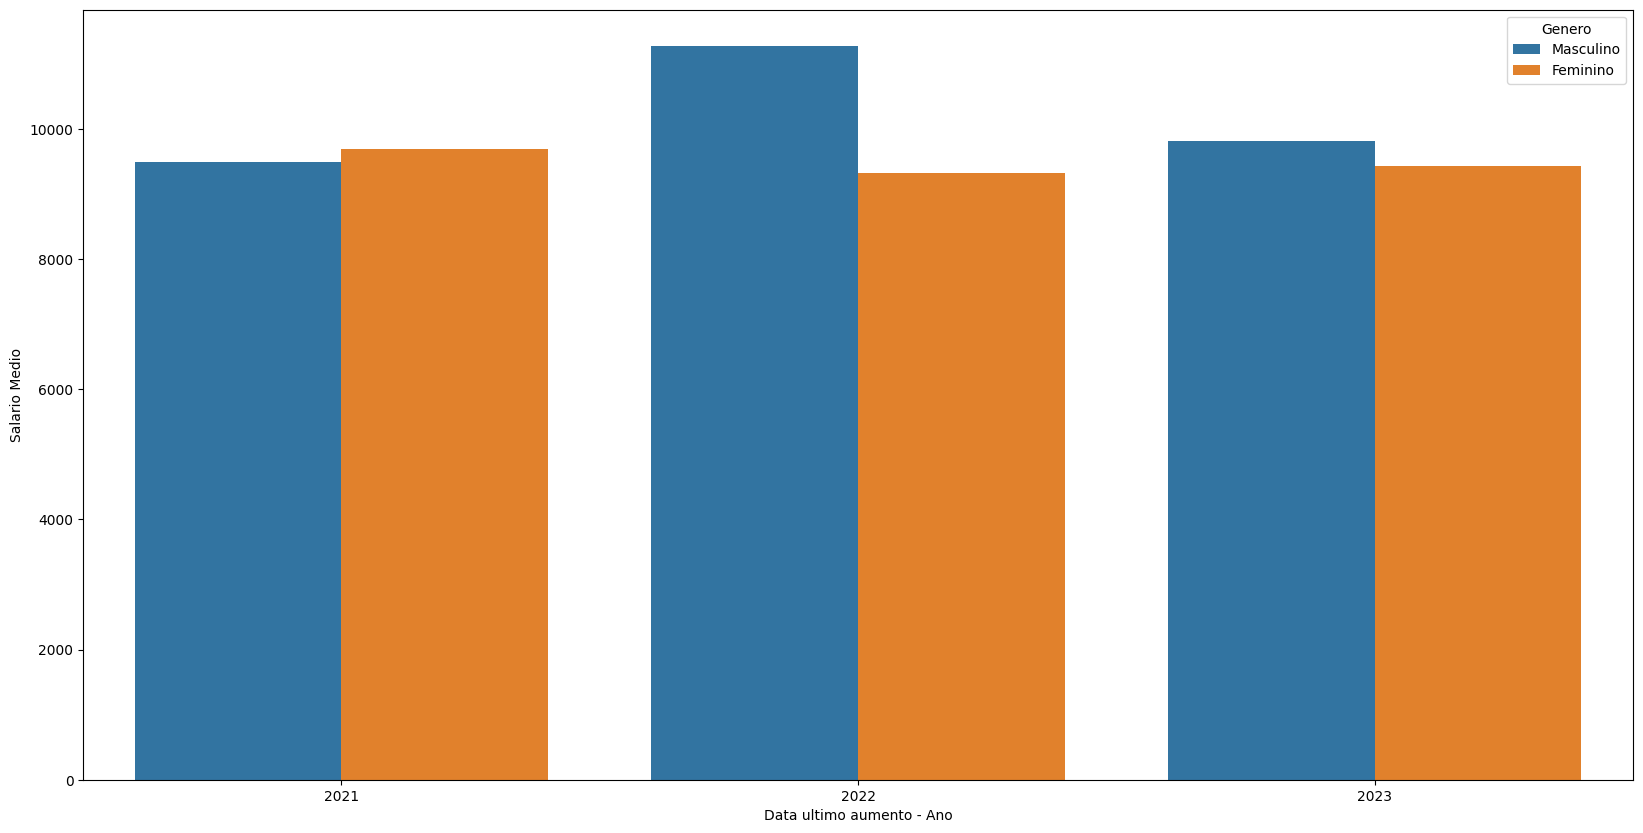

In [43]:
# Visualizando a média salarial por ano
plt.figure(figsize=(20,10))
sns.barplot(x='Data ultimo aumento - Ano', y='Salario Medio', hue='Genero', data=media_salarial_ano, hue_order=['Masculino', 'Feminino'])

---
### 3. Distribuição salarial por nível de senioridade e gênero

In [44]:
# Cálculo da média por nível do cargo e gênero
media_nivel_cargo = df.groupby(['Genero', 'Nivel'])['Faixa Salarial – numero'].mean()
media_nivel_cargo.head()

Genero     Nivel 
Feminino   Gestor    16491.803279
           Júnior     4985.074627
           Pleno      8910.569106
           Sênior    12386.363636
Masculino  Gestor    16514.285714
Name: Faixa Salarial – numero, dtype: float64

In [45]:
# Função reset_index para ordenação e transformação em DataFrame
media_nivel_cargo = media_nivel_cargo.reset_index(name='Salario Medio')
media_nivel_cargo.head(10)

,Genero,Nivel,Salario Medio
0,Feminino,Gestor,16491.803279
1,Feminino,Júnior,4985.074627
2,Feminino,Pleno,8910.569106
3,Feminino,Sênior,12386.363636
4,Masculino,Gestor,16514.285714
5,Masculino,Júnior,4450.909091
6,Masculino,Pleno,9170.347003
7,Masculino,Sênior,14592.198582


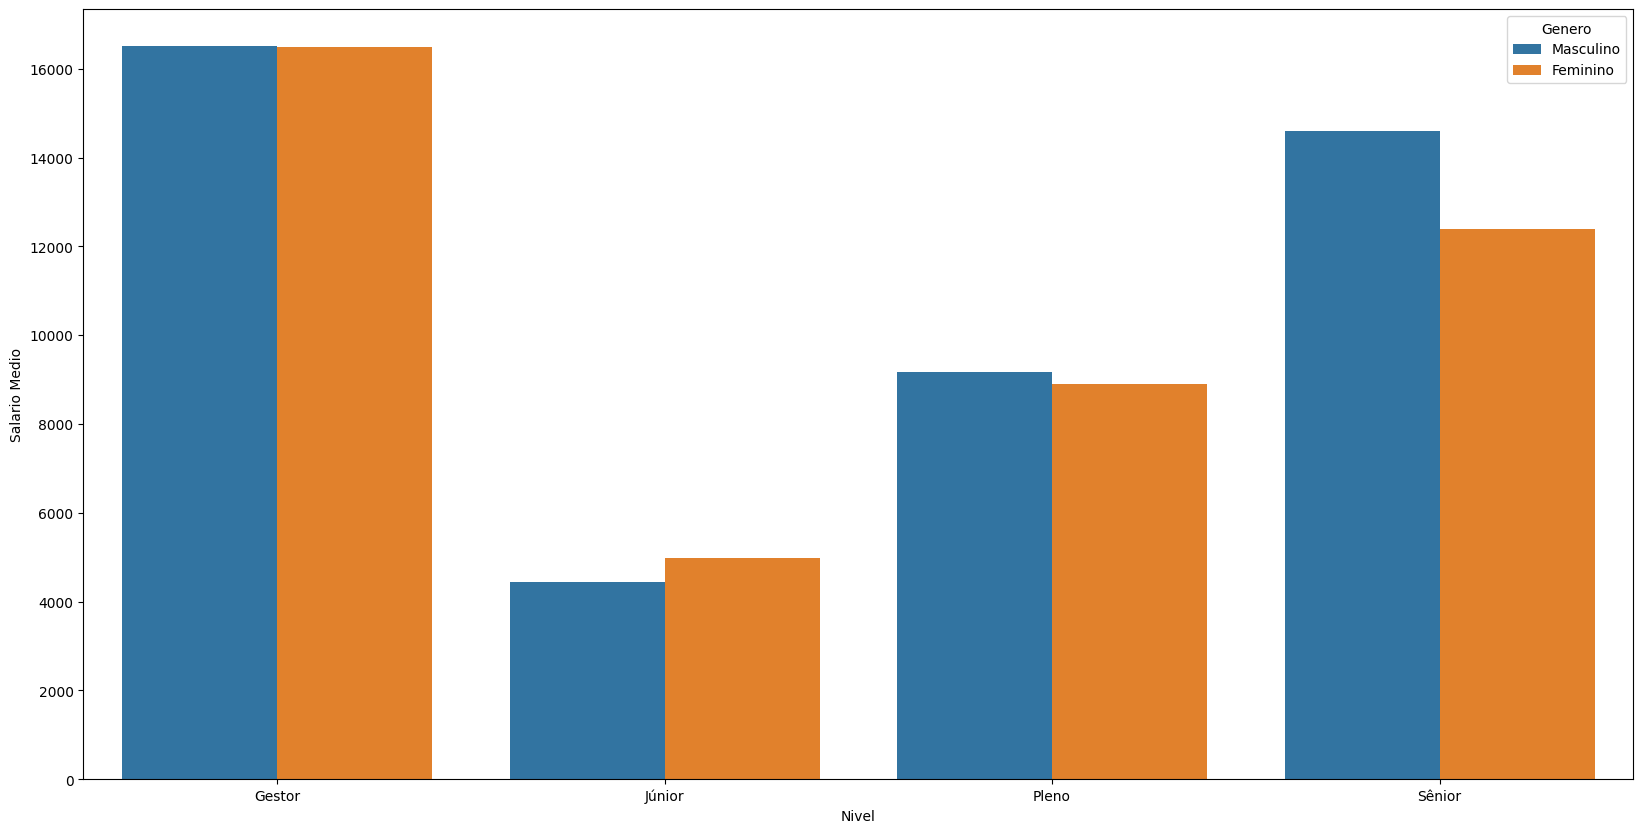

In [46]:
# Visualizando a média salarial por nível do cargo
plt.figure(figsize=(20,10))
sns.barplot(x='Nivel', y='Salario Medio', hue='Genero', data=media_nivel_cargo, hue_order=['Masculino', 'Feminino']);

---
### 4. Distribuição salarial por anos de experiência e gênero

<Axes: >

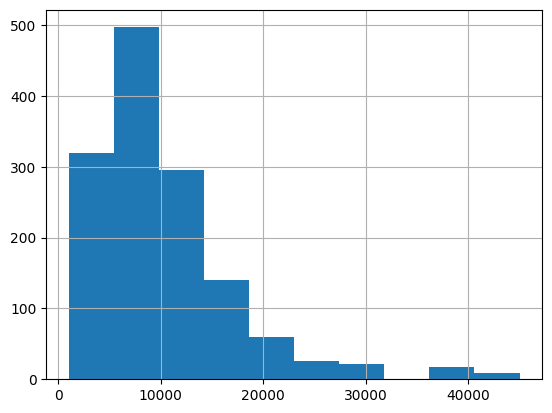

In [47]:
df['Faixa Salarial – numero'].hist()

In [48]:
# Cálculo da média por anos de experiência e gênero
media_anos_experiencia = df.groupby(['Genero', 'Anos experiencia'])['Faixa Salarial – numero'].mean()
media_anos_experiencia.head()

Genero    Anos experiencia
Feminino  Mais de 10 anos     15083.333333
          Menos de 1 ano       5388.888889
          de 1 a 2 anos        7540.229885
          de 2 a 3 anos        9512.195122
          de 4 a 5 anos       11685.714286
Name: Faixa Salarial – numero, dtype: float64

In [ ]:
# Função reset_index para ordenação e transformação em DataFrame
media_anos_experiencia = media_anos_experiencia.reset_index(name='Salario Medio')
media_anos_experiencia.head(10)

,Genero,Anos experiencia,Salario Medio
0,Feminino,Mais de 10 anos,15083.333333
1,Feminino,Menos de 1 ano,5388.888889
2,Feminino,de 1 a 2 anos,7540.229885
3,Feminino,de 2 a 3 anos,9512.195122
4,Feminino,de 4 a 5 anos,11685.714286


<Axes: xlabel='Anos experiencia', ylabel='Salario Medio'>

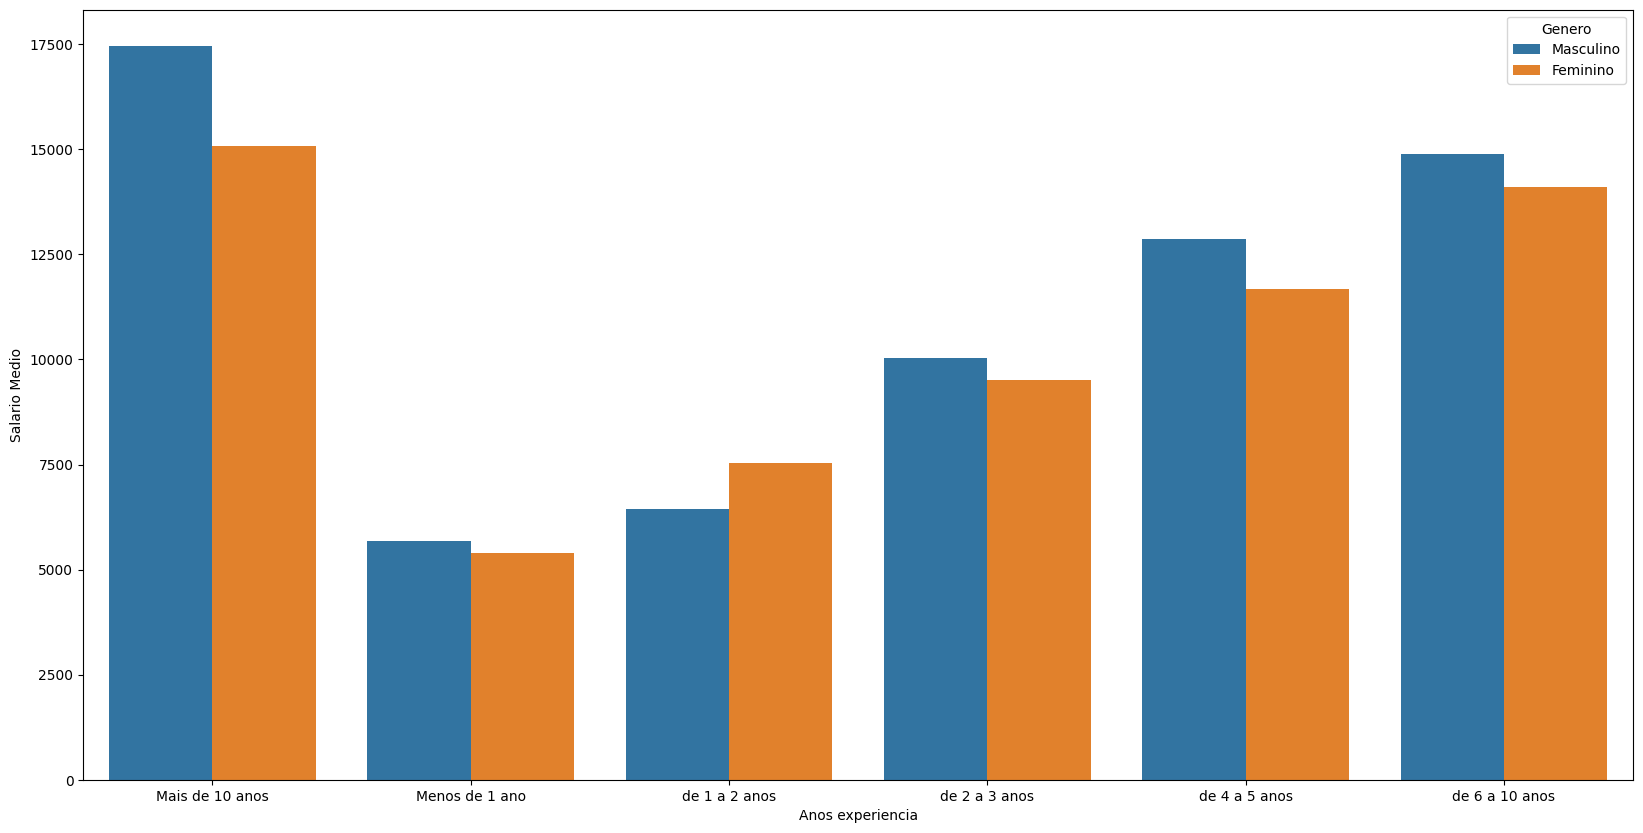

In [50]:
# Visualizando a média salarial por nível do cargo
plt.figure(figsize=(20,10))
sns.barplot(x='Anos experiencia', y='Salario Medio', hue='Genero', data=media_anos_experiencia, hue_order=['Masculino', 'Feminino'])